# 2D Flight Optimization

Given an existing flight, we can optimize its vertical profile and speed schedule while re-using the same horizontal footprint. We call this **2D flight (or vertical) optimization**: latitude and longitude are pinned to the flown values, and the optimizer solves for the flight level and Mach number along that track. Because a level change may be more straightforward for an airline than a horizontal reroute, 2D-only solutions may be more realistically flyable than full 4D optimized routes. In addition, a 4D optimizer is unaware of airspace closures and may fly through them, whereas a 2D optimizer re-uses a track that was actually flown and so is less likely to cross through closed airspace.

This notebook works through a complete end-to-end example of 2D flight optimization.

In [1]:
import io
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from pycontrails import Flight, MetDataArray, MetDataset
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.cocipgrid import CocipGrid
from pycontrails.models.humidity_scaling import HistogramMatching
from pycontrails.models.ps_model import PSFlight, PSGrid
from pycontrails.physics import units

from contrailopt import Optimizer

## ADS-B

Pull a few hours of ADS-B telemetry from the [Contrails API](https://api.contrails.org) and pick out a single flight. The cell below requires a `CONTRAILS_API_KEY` environment variable.

In [2]:
URL = "https://api.contrails.org"
API_KEY = os.environ["CONTRAILS_API_KEY"]
HEADERS = {"x-api-key": API_KEY}


adsb_dfs = []
for t in pd.date_range("2026-01-01", "2026-01-01T12", freq="h"):
    params = {"date": t.strftime("%Y-%m-%dT%H")}

    r = requests.get(f"{URL}/v1/adsb/telemetry", params=params, headers=HEADERS, timeout=120)
    r.raise_for_status()

    adsb_df = pd.read_parquet(io.BytesIO(r.content))
    adsb_dfs.append(adsb_df)

adsb_df = pd.concat(adsb_dfs)

In [3]:
fid = "2ee6d98d-8d68-486e-a73b-0f2e46fdadd5"  # cherry-picked to include contrails

fdf = (
    adsb_df.query("flight_id == @fid")
    .rename(
        columns={
            "timestamp": "time",
            "altitude_baro": "altitude_ft",
            "aircraft_type_icao": "aircraft_type",
        }
    )
    .sort_values("time")
)

fl = Flight(fdf, flight_id=fid)
fl

Flight [19 keys x 515 length, 1 attributes]
	Keys: latitude, longitude, collection_type, altitude_ft, altitude_gnss, ..., time
	Attributes:
	time                [2026-01-01 05:26:29, 2026-01-01 09:31:01]
	longitude           [-122.491, -99.081]
	latitude            [19.374, 37.806]
	altitude            [15.2, 11902.4]
	flight_id           2ee6d98d-8d68-486e-a73b-0f2e46fdadd5

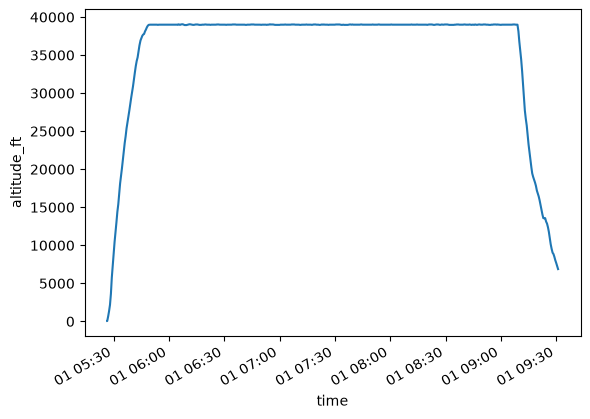

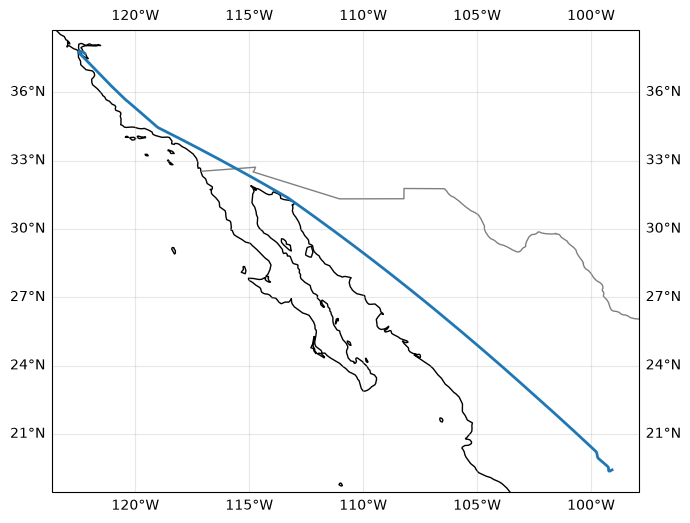

In [4]:
fl.plot_profile()
plt.show()

_, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="gray")
ax.gridlines(draw_labels=True, alpha=0.3)
ax.plot(fl["longitude"], fl["latitude"], transform=ccrs.PlateCarree(), linewidth=2)
plt.show()

## Weather

Fetch [ERA5](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels) meteorology and radiation covering the flight. This is used to compute contrail warming estimates via [CoCiP](https://elib.dlr.de/68002/) as well as aircraft performance estimates during optimization.

In [5]:
max_age = pd.Timedelta(hours=10)  # used within CocipGrid below

era5 = ERA5(
    time=(fl.time_start, fl.time_end + max_age + pd.Timedelta(hours=1)),
    variables=CocipGrid.ecmwf_met_variables(),
    pressure_levels=[175, 200, 225, 250, 300, 350],  # important to cover all cruise FLs
)
met = era5.open_metdataset()


era5 = ERA5(
    time=(fl.time_start, fl.time_end + max_age + pd.Timedelta(hours=1)),
    variables=CocipGrid.ecmwf_rad_variables(),
)
rad = era5.open_metdataset()

## Contrail warming

Run the pycontrails [gridded CoCiP](https://gmd.copernicus.org/articles/18/253/2025/) model to estimate contrail warming over the flight footprint.

In [6]:
ERF_RATIO = 0.42  # effective radiative forcing ratio, https://www.sciencedirect.com/science/article/pii/S1352231020305689

cg = CocipGrid(
    met=met,
    rad=rad,
    dt_integration=pd.Timedelta(minutes=10),
    max_age=max_age,
    aircraft_performance=PSGrid(maxiter=20),  # avoid benign pycontrails warning
    aircraft_type=fl.get_constant("aircraft_type"),
    humidity_scaling=HistogramMatching(level_type="pressure"),
    show_progress=False,
)

# Start with a buffered bounding box containing the flight
coords = fl.downselect_met(met, longitude_buffer=(10, 10), latitude_buffer=(10, 10)).coords

# Add all flight levels
coords["level"] = units.ft_to_pl(np.arange(28000, 42000, 1000))

# And the relevant times
coords["time"] = pd.date_range(fl.time_start.floor("1h"), fl.time_end.ceil("1h"), freq="1h")

source = MetDataset.from_coords(**coords)
res = cg.eval(source)

eef_per_m = MetDataArray(res["ef_per_m"].data * ERF_RATIO)
eef_per_m.attrs["long_name"] = "Effective energy forcing per meter"

## Cost optimization

Build an `Optimizer` from the flight and solve it under several cost settings, comparing each optimized profile against the one actually flown.

With `use_flown_climb_descent=True`, the flown initial climb and final descent are kept unchanged, and only the cruise phase itself is optimized.

In [7]:
opt = Optimizer.from_flight(fl, met=met, eef=eef_per_m, use_flown_climb_descent=True)

In [8]:
opt.solve(cost_index=5)
fl_opt_5 = opt.to_flight()

opt.solve(cost_index=60)
fl_opt_60 = opt.to_flight()

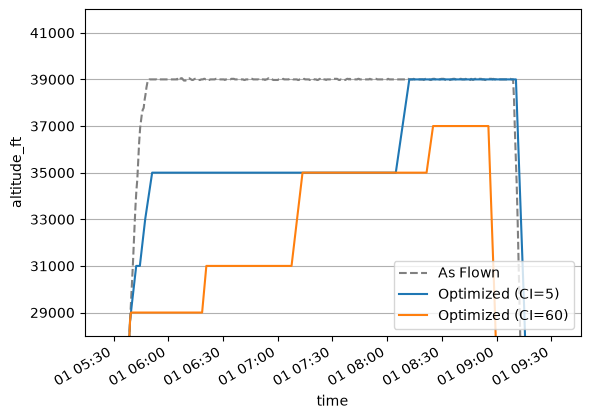

In [9]:
ax = fl.plot_profile(label="As Flown", color="0.5", style="--")
fl_opt_5.plot_profile(ax=ax, label="Optimized (CI=5)")
fl_opt_60.plot_profile(ax=ax, label="Optimized (CI=60)")

ax.set_yticks(opt.fl_choices)
ax.set_ylim(28000, 42000)
ax.grid(True, axis="y")
ax.legend()
plt.show()

## Contrail-aware optimization

Include a `dollar_tonne_co2e` term in the cost function to mitigate contrail warming.

In [10]:
opt.solve(cost_index=30, dollar_tonne_co2e=0)
fl_opt_30 = opt.to_flight()

opt.solve(cost_index=30, dollar_tonne_co2e=5)
fl_opt_con = opt.to_flight()

In [11]:
# Visualization artifacts
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "RdBu_r_warm", mpl.colormaps["RdBu_r"](np.linspace(0.5, 1.0, 256))
)
ef_curtain = fl.intersect_met_cross_section(eef_per_m)

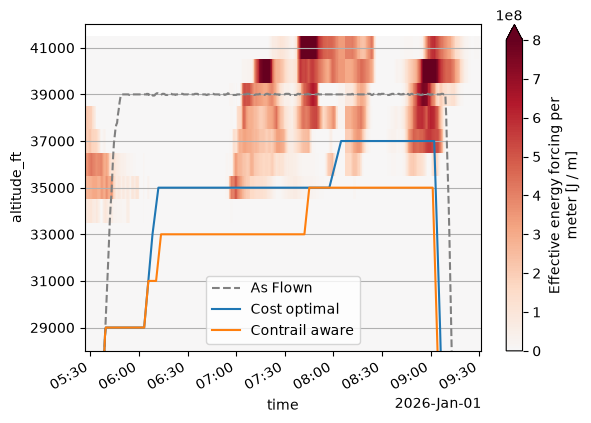

In [12]:
ax = fl.plot_profile(label="As Flown", color="0.5", style="--")
fl_opt_30.plot_profile(ax=ax, label="Cost optimal")
fl_opt_con.plot_profile(ax=ax, label="Contrail aware")

ef_curtain.plot.pcolormesh(
    x="time",
    y="altitude_ft",
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=8e8,
)

ax.set_yticks(opt.fl_choices)
ax.set_ylim(28000, 42000)
ax.grid(True, axis="y")
ax.legend()
plt.show()

### The cost of contrail mitigation

In this particular example, pricing contrails at $5/tonne CO2e cuts the trajectory's effective energy forcing from contrails to nearly zero with a small fuel burn increase compared to the cost optimal flight.

The as-flown profile reflects constraints and details the optimizer never sees: turbulence, airspace restrictions, traffic, and airline-specific forecasts and performance models. The contrail-aware and cost-optimal solutions differ only in the contrail term, so the fuel penalty of mitigation is best read from the gap between those two.

In [13]:
def estimate_costs(flight: Flight) -> dict[str, float]:
    """Estimate the costs of an optimized flight."""
    flight = flight.copy()  # avoid mutation

    waypoint_eef = flight["eef_per_m"] if "eef_per_m" in flight else flight.intersect_met(eef_per_m)
    seg_eef = waypoint_eef * flight.segment_length()
    total_eef = np.nansum(seg_eef).item()

    if "air_temperature" not in flight:
        flight["air_temperature"] = flight.intersect_met(met["air_temperature"])
    if "u_wind" not in flight:
        flight["u_wind"] = flight.intersect_met(met["eastward_wind"])
    if "v_wind" not in flight:
        flight["v_wind"] = flight.intersect_met(met["northward_wind"])

    flight.attrs.setdefault("flight_id", "dummy")  # avoid pycontrails warning
    total_fuel = PSFlight().eval(flight).attrs["total_fuel_burn"]

    duration_minutes = flight.duration.total_seconds() / 60.0

    return {"eef_TJ": total_eef / 1e12, "fuel_kg": total_fuel, "duration_minutes": duration_minutes}


# Build a DataFrame for presentation only
pd.DataFrame.from_dict(
    {
        "as flown": estimate_costs(fl),
        "cost optimal": estimate_costs(fl_opt_30),
        "contrail aware": estimate_costs(fl_opt_con),
    },
    orient="index",
).round(1)

,eef_TJ,fuel_kg,duration_minutes
as flown,387.2,8866.3,244.5
cost optimal,279.0,8706.1,237.8
contrail aware,1.4,8838.8,235.8


## Aside: Reduce yoyos

A yoyo is a cruise profile that steps repeatedly to chase small gains. The contrail-aware solution above demonstrates this: the initial climb levels off at FL290, and the optimizer then steps to FL310, to FL330, and finally to FL350.

The solver has no reason to avoid this: it already accounts for the fuel and time of each maneuver, so every step it takes is worth taking on its own terms. However, it can't see the operational cost of a clearance request and extra strain on the crew.

The `step_penalty_kg` adds a fixed fuel charge to every step climb and descent, on top of the maneuver's modeled cost. Raising it encourages a flatter, more flyable profile. The initial climb and final descent are exempt.

Below, a 1 kg penalty drops the FL310 step climb, and a 100 kg penalty leaves a single climb to FL330 for the whole cruise.

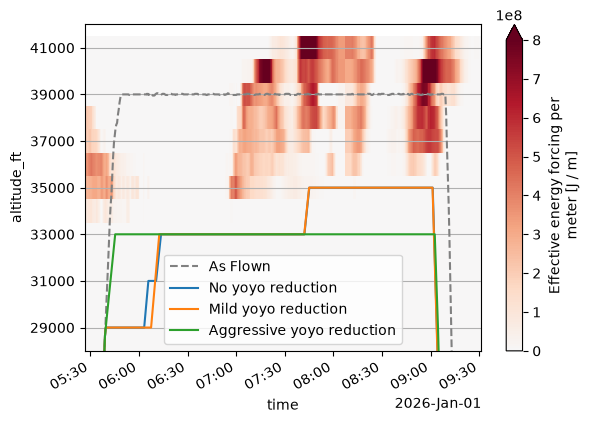

In [14]:
opt.solve(cost_index=30, dollar_tonne_co2e=5, step_penalty_kg=1)
fl_opt_mild = opt.to_flight()

opt.solve(cost_index=30, dollar_tonne_co2e=5, step_penalty_kg=100)
fl_opt_aggressive = opt.to_flight()

ax = fl.plot_profile(label="As Flown", color="0.5", style="--")
fl_opt_con.plot_profile(ax=ax, label="No yoyo reduction")
fl_opt_mild.plot_profile(ax=ax, label="Mild yoyo reduction")
fl_opt_aggressive.plot_profile(ax=ax, label="Aggressive yoyo reduction")


ef_curtain.plot.pcolormesh(
    x="time",
    y="altitude_ft",
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=8e8,
)

ax.set_yticks(opt.fl_choices)
ax.set_ylim(28000, 42000)
ax.grid(True, axis="y")
ax.legend()
plt.show()